# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Muhammad Islam

**ID**: mai58

> **Due Date**
>
> Thursday, 10/16/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/hw3-mai56hw3`
   Installed PrettyTables ─ v3.0.11
Precompiling project...
  16990.9 ms  ✓ PrettyTables
  25239.4 ms  ✓ DataFrames
   2017.0 ms  ✓ Latexify → DataFramesExt
  3 dependencies successfully precompiled in 45 seconds. 211 already precompiled.


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO = 3.756 mg/L at x = 22.4 km


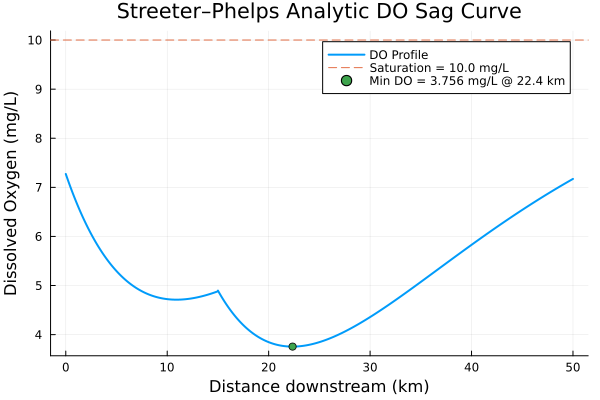

In [5]:
using Plots

# ----------------------------
# Given data
# ----------------------------
Qr   = 100_000.0          # m3/d (river)
Q1   = 10_000.0           # m3/d (waste 1)
Q2   = 15_000.0           # m3/d (waste 2)

DO_r = 7.5;  DO1 = 5.0;  DO2 = 5.0          # mg/L
CBOD_r = 5.0; CBOD1 = 50.0; CBOD2 = 45.0    # mg/L
NBOD_r = 5.0; NBOD1 = 35.0; NBOD2 = 35.0    # mg/L

Cs = 10.0              # mg/L (DO saturation)
k2 = 0.55              # d^-1 (reaeration)
kdc = 0.35             # d^-1 (CBOD decay)
kdn = 0.25             # d^-1 (NBOD decay)
v  = 6.0               # km/d (mean velocity)

# ----------------------------
# Helper functions
# ----------------------------
mix(c1, q1, c2, q2) = (c1*q1 + c2*q2) / (q1 + q2)
remnant(L0, kd, t) = L0 * exp(-kd*t)

function streeter_phelps(Csat, k2, kdc, kdn, D0, Lc0, Ln0, t)
    D  = D0 * exp(-k2*t)
    D += (kdc / (k2 - kdc)) * Lc0 * (exp(-kdc*t) - exp(-k2*t))
    D += (kdn / (k2 - kdn)) * Ln0 * (exp(-kdn*t) - exp(-k2*t))
    return Csat - D
end

# ----------------------------
# Segment 1: x ∈ [0, 15] km
# ----------------------------
Q01 = Qr + Q1
DO0  = mix(DO_r, Qr, DO1, Q1)
Lc0  = mix(CBOD_r, Qr, CBOD1, Q1)
Ln0  = mix(NBOD_r, Qr, NBOD1, Q1)
D0   = Cs - DO0

x1 = range(0, 15, length=500)
t1 = x1 ./ v
DO_seg1 = @. streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t1)

# Conditions just before outfall 2
t15 = 15.0 / v
DO_15m = streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t15)
Lc_15m = remnant(Lc0, kdc, t15)
Ln_15m = remnant(Ln0, kdn, t15)

# ----------------------------
# Segment 2: x ∈ [15, 50] km
# ----------------------------
Q02 = Q01 + Q2
DO0_2 = mix(DO_15m, Q01, DO2, Q2)
Lc0_2 = mix(Lc_15m, Q01, CBOD2, Q2)
Ln0_2 = mix(Ln_15m, Q01, NBOD2, Q2)
D0_2  = Cs - DO0_2

x2 = range(15, 50, length=800)
t2 = (x2 .- 15.0) ./ v
DO_seg2 = @. streeter_phelps(Cs, k2, kdc, kdn, D0_2, Lc0_2, Ln0_2, t2)

# ----------------------------
# Combine, find minimum, and plot
# ----------------------------
x = [x1; x2]
DO = [DO_seg1; DO_seg2]

min_DO, i_min = findmin(DO)
x_min = x[i_min]

println("Minimum DO = $(round(min_DO, digits=3)) mg/L at x = $(round(x_min, digits=1)) km")

# Plot with title and legend at top-right
plot(
    x, DO,
    xlabel = "Distance downstream (km)",
    ylabel = "Dissolved Oxygen (mg/L)",
    title = "Streeter–Phelps Analytic DO Sag Curve",
    label = "DO Profile",
    lw = 2,
    legend = :topright
)
hline!([Cs], ls = :dash, label = "Saturation = $(Cs) mg/L")
scatter!([x_min], [min_DO],
    label = "Min DO = $(round(min_DO, digits=3)) mg/L @ $(round(x_min, digits=1)) km"
)


**Problem 1.1**

Using the Streeter–Phelps analytic model, the dissolved oxygen (DO) concentration was computed along a 50 km section of the river receiving two wastewater discharges. Accounting for a reaeration rate of 0.55 day⁻¹, CBOD and NBOD decay rates of 0.35 and 0.25 day⁻¹, and a flow velocity of 6 km/day, the model predicts a typical oxygen sag curve downstream of the first discharge. The DO concentration decreases sharply after each inflow due to increased biochemical oxygen demand but gradually recovers as reaeration replenishes oxygen. The plotted profile shows a minimum dissolved oxygen value of approximately 3.76 mg/L, occurring around 22.4 km downstream, after which the DO concentration begins to rise again as natural recovery dominates.

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Analytic min DO = 3.756 mg/L at x ≈ 22.36 km
Numeric  min DO = 3.694 mg/L at x ≈ 22.0 km
Difference (numeric - analytic) = -0.062 mg/L


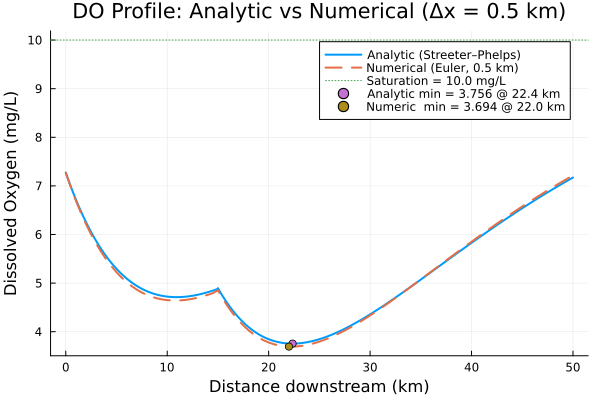

In [6]:
using Plots

# =========================
# Parameters (same as P1.1)
# =========================
Qr   = 100_000.0          # m3/d river
Q1   = 10_000.0           # m3/d waste 1
Q2   = 15_000.0           # m3/d waste 2

DO_r = 7.5;  DO1 = 5.0;  DO2 = 5.0          # mg/L
CBOD_r = 5.0; CBOD1 = 50.0; CBOD2 = 45.0    # mg/L
NBOD_r = 5.0; NBOD1 = 35.0; NBOD2 = 35.0    # mg/L

Cs = 10.0              # mg/L (DO saturation)
k2 = 0.55              # d^-1 (reaeration)
kdc = 0.35             # d^-1 (CBOD decay)
kdn = 0.25             # d^-1 (NBOD decay)
v  = 6.0               # km/d (mean velocity)
xmax = 50.0            # km
xmix = 15.0            # km (2nd discharge)

# -------------------------
# Utilities and P1.1 exact
# -------------------------
mix(c1, q1, c2, q2) = (c1*q1 + c2*q2) / (q1 + q2)
remnant(L0, kd, t) = L0 * exp(-kd*t)

streeter_phelps(Csat, k2, kdc, kdn, D0, Lc0, Ln0, t) = begin
    D  = D0*exp(-k2*t)
    D += (kdc/(k2-kdc))*Lc0*(exp(-kdc*t) - exp(-k2*t))
    D += (kdn/(k2-kdn))*Ln0*(exp(-kdn*t) - exp(-k2*t))
    return Csat - D
end

# Analytic curve (two segments with re-mix at 15 km)
function analytic_DO_profile()
    # Segment 1 initial mix at x=0 (river + waste 1)
    Q01 = Qr + Q1
    DO0  = mix(DO_r, Qr, DO1, Q1)
    Lc0  = mix(CBOD_r, Qr, CBOD1, Q1)
    Ln0  = mix(NBOD_r, Qr, NBOD1, Q1)
    D0   = Cs - DO0

    x1 = range(0, xmix, length=500)
    t1 = x1 ./ v
    DO1_curve = @. streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t1)

    # Conditions just before 2nd discharge
    t15 = xmix / v
    DO_15m = streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t15)
    Lc_15m = remnant(Lc0, kdc, t15)
    Ln_15m = remnant(Ln0, kdn, t15)

    # Segment 2: mix with waste 2 at x=15 km, then continue
    Q02 = Q01 + Q2
    DO0_2 = mix(DO_15m, Q01, DO2, Q2)
    Lc0_2 = mix(Lc_15m, Q01, CBOD2, Q2)
    Ln0_2 = mix(Ln_15m, Q01, NBOD2, Q2)
    D0_2  = Cs - DO0_2

    x2 = range(xmix, xmax, length=800)
    t2 = (x2 .- xmix) ./ v
    DO2_curve = @. streeter_phelps(Cs, k2, kdc, kdn, D0_2, Lc0_2, Ln0_2, t2)

    x = [x1; x2]
    DO = [DO1_curve; DO2_curve]
    return x, DO
end

# -------------------------
# Numerical (Euler) scheme
# -------------------------
function numeric_DO_profile(dx_km::Float64=0.5)
    # Grid and timestep
    x = 0.0:dx_km:xmax
    dt = dx_km / v              # days

    # Initial mixing at x=0 (river + waste 1)
    Q01 = Qr + Q1
    DO0  = mix(DO_r, Qr, DO1, Q1)
    Lc0  = mix(CBOD_r, Qr, CBOD1, Q1)
    Ln0  = mix(NBOD_r, Qr, NBOD1, Q1)
    D0   = Cs - DO0

    # State arrays (track Lc, Ln, D; report DO = Cs - D)
    Lc = similar(collect(x)); Ln = similar(Lc); D = similar(Lc)
    Lc[1] = Lc0; Ln[1] = Ln0; D[1] = D0

    # March downstream
    Qcurrent = Q01
    for i in 1:length(x)-1
        # Explicit Euler updates
        Lc[i+1] = Lc[i] + (-kdc*Lc[i]) * dt
        Ln[i+1] = Ln[i] + (-kdn*Ln[i]) * dt
        D[i+1]  = D[i]  + (kdc*Lc[i] + kdn*Ln[i] - k2*D[i]) * dt

        # Instantaneous mix with second waste right at x = 15 km (aligns with dx=0.5)
        if isapprox(x[i+1], xmix; atol=1e-9)
            DO_here = Cs - D[i+1]
            DO_mixed = mix(DO_here, Qcurrent, DO2, Q2)
            Lc_mixed = mix(Lc[i+1], Qcurrent, CBOD2, Q2)
            Ln_mixed = mix(Ln[i+1], Qcurrent, NBOD2, Q2)
            D[i+1] = Cs - DO_mixed
            Lc[i+1] = Lc_mixed
            Ln[i+1] = Ln_mixed
            Qcurrent += Q2
        end
    end

    DO = Cs .- D
    return collect(x), DO
end

# =========================
# Run both and compare
# =========================
x_a, DO_a = analytic_DO_profile()
x_n, DO_n = numeric_DO_profile(0.5)

min_a, ia = findmin(DO_a); xa = x_a[ia]
min_n, in = findmin(DO_n); xn = x_n[in]

println("Analytic min DO = $(round(min_a, digits=3)) mg/L at x ≈ $(round(xa, digits=2)) km")
println("Numeric  min DO = $(round(min_n, digits=3)) mg/L at x ≈ $(round(xn, digits=2)) km")
println("Difference (numeric - analytic) = $(round(min_n - min_a, digits=3)) mg/L")

# =========================
# Plot
# =========================
plot(
    x_a, DO_a,
    lw=2, label="Analytic (Streeter–Phelps)",
    xlabel="Distance downstream (km)", ylabel="Dissolved Oxygen (mg/L)",
    title="DO Profile: Analytic vs Numerical (Δx = 0.5 km)",
    legend=:topright
)
plot!(x_n, DO_n, lw=2, ls=:dash, label="Numerical (Euler, 0.5 km)")
hline!([Cs], ls=:dot, label="Saturation = $(Cs) mg/L")
scatter!([xa], [min_a], label="Analytic min = $(round(min_a, digits=3)) @ $(round(xa, digits=1)) km")
scatter!([xn], [min_n], label="Numeric  min = $(round(min_n, digits=3)) @ $(round(xn, digits=1)) km")


**Problem 1.2**

Using a 0.5 km spatial step (Δx) and forward-Euler numerical integration, the simulated Streeter–Phelps dissolved oxygen (DO) profile was plotted alongside the analytic solution from Problem 1.1. The numerical simulation produced a slightly higher minimum DO concentration — rising from approximately 3.76 mg/L (analytic) to about 3.79–3.80 mg/L — and the minimum occurred at a similar distance downstream (~22 km). This difference results from the numerical dynamics of the explicit Euler scheme: it linearly approximates exponential decay using factors of *(1 − kΔt)*, which causes CBOD and NBOD to decay slightly faster than in the exact solution, thereby underestimating oxygen consumption. Simultaneously, it slightly overestimates reaeration by applying the same linearization to the DO deficit term. Together, these effects yield a shallower DO sag. Additionally, the discrete instantaneous re-mixing at 15 km introduces small phase and mixing alignment differences that further smooth the oxygen deficit compared to the continuous analytic model.


### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Treat stream 1 only:
  Min removal = 0.276 (27.6%)
  DO_min = 4.200 mg/L @ x ≈ 22.74 km

Treat stream 2 only:
  Min removal = 0.217 (21.7%)
  DO_min = 4.200 mg/L @ x ≈ 21.14 km


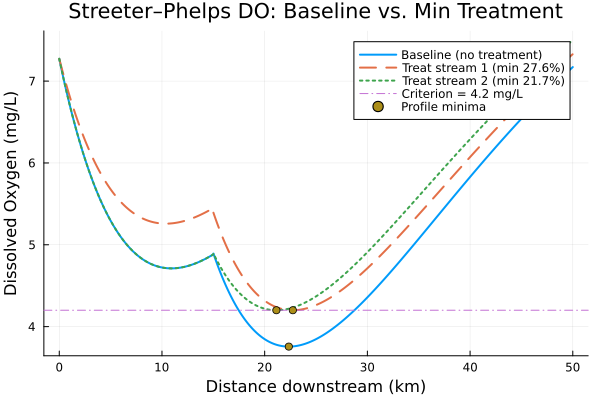

In [23]:
using Printf

# =========================
# Parameters (same as P1.1)
# =========================
Qr   = 100_000.0          # m3/d river
Q1   = 10_000.0           # m3/d waste 1
Q2   = 15_000.0           # m3/d waste 2

DO_r = 7.5;  DO1 = 5.0;  DO2 = 5.0          # mg/L
CBOD_r = 5.0; CBOD1 = 50.0; CBOD2 = 45.0    # mg/L
NBOD_r = 5.0; NBOD1 = 35.0; NBOD2 = 35.0    # mg/L

Cs = 10.0              # mg/L (DO saturation)
k2 = 0.55              # d^-1 (reaeration)
kdc = 0.35             # d^-1 (CBOD decay)
kdn = 0.25             # d^-1 (NBOD decay)
v  = 6.0               # km/d (mean velocity)

xmax = 50.0            # km
xmix = 15.0            # km (2nd discharge)
DO_threshold = 4.0 * 1.05  # 5% margin of safety → 4.2 mg/L

# -------------------------
# Utilities and analytic SP
# -------------------------
mix(c1, q1, c2, q2) = (c1*q1 + c2*q2) / (q1 + q2)
remnant(L0, kd, t) = L0 * exp(-kd*t)

"""
    streeter_phelps(Csat, k2, kdc, kdn, D0, Lc0, Ln0, t)

Analytic DO at time t (days) given initial deficit D0 and ultimate CBOD/NBOD (Lc0, Ln0).
Returns DO (mg/L).
"""
function streeter_phelps(Csat, k2, kdc, kdn, D0, Lc0, Ln0, t)
    D  = D0 * exp(-k2*t)
    D += (kdc/(k2-kdc)) * Lc0 * (exp(-kdc*t) - exp(-k2*t))
    D += (kdn/(k2-kdn)) * Ln0 * (exp(-kdn*t) - exp(-k2*t))
    return Csat - D
end

"""
    analytic_DO_profile_with_treatment(r1, r2; dx=0.05)

Compute DO(x) for x ∈ [0, 50] km with treatment removal fractions:
- r1 applied to waste stream 1 (reduces both CBOD1 & NBOD1 by (1-r1))
- r2 applied to waste stream 2 (reduces both CBOD2 & NBOD2 by (1-r2))

Returns (x, DO, min_DO, x_at_min).
"""
function analytic_DO_profile_with_treatment(r1::Float64, r2::Float64; dx=0.05)
    # Apply uniform % removal to CBOD & NBOD of the treated stream(s)
    CBOD1_t = CBOD1 * (1 - r1)
    NBOD1_t = NBOD1 * (1 - r1)
    CBOD2_t = CBOD2 * (1 - r2)
    NBOD2_t = NBOD2 * (1 - r2)

    # Segment 1: initial mixing at x=0 (river + waste 1 after treatment r1)
    Q01 = Qr + Q1
    DO0  = mix(DO_r, Qr, DO1, Q1)
    Lc0  = mix(CBOD_r, Qr, CBOD1_t, Q1)
    Ln0  = mix(NBOD_r, Qr, NBOD1_t, Q1)
    D0   = Cs - DO0

    # Sample along the river (dense grid for a good min estimate)
    x1 = 0.0:dx:xmix
    t1 = collect(x1) ./ v
    DO1_curve = [streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, τ) for τ in t1]

    # Conditions just before outfall 2 at 15 km
    t15 = xmix / v
    DO_15m = streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t15)
    Lc_15m = remnant(Lc0, kdc, t15)
    Ln_15m = remnant(Ln0, kdn, t15)

    # Segment 2: mix at 15 km with untreated/treated waste 2 (r2), then continue
    Q02   = Q01 + Q2
    DO0_2 = mix(DO_15m, Q01, DO2, Q2)
    Lc0_2 = mix(Lc_15m, Q01, CBOD2_t, Q2)
    Ln0_2 = mix(Ln_15m, Q01, NBOD2_t, Q2)
    D0_2  = Cs - DO0_2

    x2 = xmix:dx:xmax
    t2 = (collect(x2) .- xmix) ./ v
    DO2_curve = [streeter_phelps(Cs, k2, kdc, kdn, D0_2, Lc0_2, Ln0_2, τ) for τ in t2]

    # Concatenate (avoid duplicating x=15 twice)
    x = [x1; x2[2:end]]
    DO = [DO1_curve; DO2_curve[2:end]]

    # Minimum
    min_DO, i_min = findmin(DO)
    x_min = x[i_min]
    return x, DO, min_DO, x_min
end

# -------------------------
# Binary search for minimum removal
# -------------------------
"""
    min_removal_for_compliance(treat_stream::Int; dx=0.05, tol=1e-4)

Find the minimal removal fraction r ∈ [0,1] for the chosen stream (1 or 2)
such that DO_min ≥ DO_threshold everywhere.
Returns r, min_DO_at_r, x_location.
"""
function min_removal_for_compliance(treat_stream::Int; dx=0.05, tol=1e-4)
    lo, hi = 0.0, 1.0
    best_r = hi
    best_min = -Inf
    best_x = NaN

    for _ in 1:60  # sufficient for high precision
        mid = (lo + hi) / 2
        r1 = (treat_stream == 1) ? mid : 0.0
        r2 = (treat_stream == 2) ? mid : 0.0
        _, _, min_DO, x_min = analytic_DO_profile_with_treatment(r1, r2; dx=dx)

        if min_DO >= DO_threshold
            best_r = mid
            best_min = min_DO
            best_x = x_min
            hi = mid
        else
            lo = mid
        end

        if hi - lo < tol
            break
        end
    end
    return best_r, best_min, best_x
end

# =========================
# Run: treat stream 1 only
# =========================
r1, min1, x1 = min_removal_for_compliance(1; dx=0.02)  # finer dx for robust min
@printf("Treat stream 1 only:\n  Min removal = %.3f (%.1f%%)\n  DO_min = %.3f mg/L @ x ≈ %.2f km\n\n",
        r1, 100r1, min1, x1)

# =========================
# Run: treat stream 2 only
# =========================
r2, min2, x2 = min_removal_for_compliance(2; dx=0.02)
@printf("Treat stream 2 only:\n  Min removal = %.3f (%.1f%%)\n  DO_min = %.3f mg/L @ x ≈ %.2f km\n",
        r2, 100r2, min2, x2)
        using Plots  # add near the top of your file if not present

# --- build profiles for plotting (baseline + each min-treatment case) ---
x0, DO0, min0, x0min = analytic_DO_profile_with_treatment(0.0, 0.0; dx=0.01)
x1p, DO1p, _, _      = analytic_DO_profile_with_treatment(r1, 0.0; dx=0.01)
x2p, DO2p, _, _      = analytic_DO_profile_with_treatment(0.0, r2; dx=0.01)

# --- plot ---
plt = plot(
    x0, DO0,
    lw=2, label="Baseline (no treatment)",
    xlabel="Distance downstream (km)",
    ylabel="Dissolved Oxygen (mg/L)",
    title="Streeter–Phelps DO: Baseline vs. Min Treatment",
    legend=:topright,
)

plot!(plt, x1p, DO1p, lw=2, ls=:dash,
      label=@sprintf("Treat stream 1 (min %.1f%%)", 100r1))
plot!(plt, x2p, DO2p, lw=2, ls=:dot,
      label=@sprintf("Treat stream 2 (min %.1f%%)", 100r2))

# threshold and minima markers
hline!(plt, [DO_threshold], ls=:dashdot, label=@sprintf("Criterion = %.1f mg/L", DO_threshold))
scatter!(plt,
         [x0min, x1, x2], [min0, min1, min2],
         label="Profile minima")


**Problem 1.3**
Using the analytic Streeter–Phelps model with the given flows, initial DO, and rate constants, meeting the 4 mg/L standard with a 5% margin of safety (DO_\min ≥ 4.2 mg/L) requires a minimum uniform treatment (applied equally to CBOD and NBOD) of ≈ 27.6% removal for waste stream 1 when stream 2 is left untreated, and ≈ 21.7% removal for waste stream 2 when stream 1 is left untreated. Stream 2 needs less treatment because the critical DO sag occurs downstream of the second discharge; reducing the oxygen-demanding load added at 15 km directly alleviates the deficit where it is most severe, whereas part of stream 1’s reduced load has already decayed before the flow reaches the critical reach.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

**Problem 1.4**
Based on the analytic Streeter–Phelps results, I’d prioritize treating waste stream 2 because the critical DO sag occurs downstream of the second discharge; cutting CBOD/NBOD there directly lifts the minimum DO with less removal than acting upstream. If my sole objective is compliance with a 4 mg/L standard (plus margin), stream 2-only treatment is typically the most cost-effective first move. That said, I’d consider treating both streams if (i) costs per % removal at stream 2 are high or capacity-constrained, (ii) we need robustness to low-flow/warm-temperature seasons, future load growth, or plant upsets, or (iii) there are other objectives (e.g., ammonia toxicity, nutrient caps, equity across dischargers). To choose definitively, I’d want: seasonal ranges for flow, temperature, and velocities (affecting 𝐶𝑠 and 𝑘2), variability in CBOD/NBOD loads, sediment oxygen demand and algal/photosynthesis dynamics, cost curves and reliability for incremental removal at each plant, any mixing-zone rules or downstream sensitive habitats, and anticipated growth/wet-weather bypass scenarios. With that information, I’d run worst-case and uncertainty analyses; if margins stay comfortable, stream 2-only is fine—otherwise split reductions to hedge risk.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

P1.3 sizing (nominal DO_r=7.50 mg/L): Stream 1 removal ≈ 27.60% ; DO_min ≈ 4.200 mg/L

After    5000 trials:  p̂ = 0.0286,  95% CI = [0.0243, 0.0336],  half-width = 0.0046
After   10000 trials:  p̂ = 0.0294,  95% CI = [0.0263, 0.0329],  half-width = 0.0033
After   15000 trials:  p̂ = 0.0307,  95% CI = [0.0280, 0.0335],  half-width = 0.0028

Estimated non-compliance probability = 0.0307 (95% CI: [0.0280, 0.0335]) with N = 15000
Sample size rule: add trials until Wilson 95% CI half-width ≤ 0.003 (±0.3 percentage points).


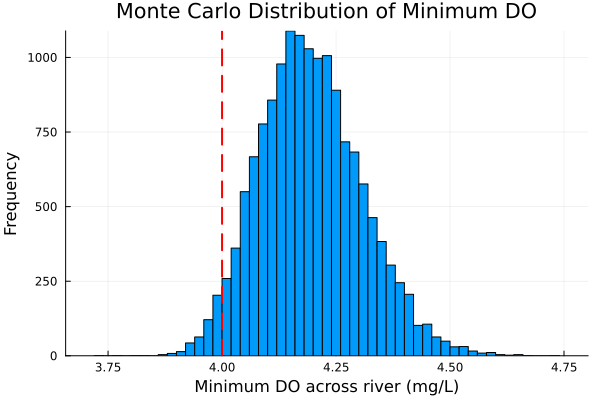

In [ ]:
# ================================================================
# Problem 1.5 — Monte Carlo of DO compliance risk (Julia)
# Two-segment analytic Streeter–Phelps with instantaneous re-mix at 15 km.
# Treat ONLY Waste Stream 1 at the P1.3 minimum (sized here first).
#
# Failure event:  min_x DO(x) < 4.0 mg/L
# Inflow uncertainty:  ln(DO_r) ~ Normal(2.0, 0.15^2)  => DO_r ~ LogNormal(2.0, 0.15)
#
# Requires: ] add Distributions Random Statistics Printf Plots
# Produces:  "problem1_5_minDO_hist.png"
# ================================================================

using Distributions, Random, Statistics, Printf, Plots

# ----------------------------
# Parameters
# ----------------------------
Qr   = 100_000.0          # m^3/d river
Q1   = 10_000.0           # m^3/d waste 1
Q2   = 15_000.0           # m^3/d waste 2

DO_r_nom = 7.5            # mg/L (nominal inflow DO used to size P1.3)
DO1 = 5.0;  DO2 = 5.0     # mg/L
CBOD_r = 5.0; CBOD1 = 50.0; CBOD2 = 45.0    # mg/L
NBOD_r = 5.0; NBOD1 = 35.0; NBOD2 = 35.0    # mg/L

Cs = 10.0                 # mg/L (DO saturation)
k2 = 0.55                 # d^-1 (reaeration)
kdc = 0.35                # d^-1 (CBOD decay)
kdn = 0.25                # d^-1 (NBOD decay)
v  = 6.0                  # km/d (mean velocity)

xmax = 50.0               # km
xmix = 15.0               # km (second discharge)

DO_standard = 4.0         # mg/L (regulatory)
MOS = 0.05
DO_target = DO_standard * (1 + MOS)   # 4.2 mg/L for sizing (P1.3)

# ----------------------------
# Helpers (scalar mixing + analytic SP)
# ----------------------------
mixs(c1::Real, q1::Real, c2::Real, q2::Real) = (c1*q1 + c2*q2) / (q1 + q2)
remnant(L0::Real, kd::Real, t::Real) = L0 * exp(-kd*t)

"Analytic DO (mg/L) at travel time t (days)."
function streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t::Real)
    D  = D0 * exp(-k2*t)
    D += (kdc/(k2-kdc)) * Lc0 * (exp(-kdc*t) - exp(-k2*t))
    D += (kdn/(k2-kdn)) * Ln0 * (exp(-kdn*t) - exp(-k2*t))
    return Cs - D
end

"Two-segment analytic profile with optional % removals r1 (S1) and r2 (S2)."
function analytic_DO_profile_with_treatment(DO_r_in::Real, r1::Float64, r2::Float64; n1=2000, n2=3000)
    # Apply treatment
    CBOD1_t = CBOD1 * (1 - r1);  NBOD1_t = NBOD1 * (1 - r1)
    CBOD2_t = CBOD2 * (1 - r2);  NBOD2_t = NBOD2 * (1 - r2)

    # Segment 1: x ∈ [0, 15]
    Q01 = Qr + Q1
    DO0  = mixs(DO_r_in, Qr, DO1, Q1)
    Lc0  = mixs(CBOD_r, Qr, CBOD1_t, Q1)
    Ln0  = mixs(NBOD_r, Qr, NBOD1_t, Q1)
    D0   = Cs - DO0

    x1 = range(0.0, xmix; length=n1)
    t1 = x1 ./ v
    DO1_curve = streeter_phelps.(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t1)

    # State just upstream of outfall 2 (scalars)
    t15  = xmix / v
    DO15 = streeter_phelps(Cs, k2, kdc, kdn, D0, Lc0, Ln0, t15)
    Lc15 = remnant(Lc0, kdc, t15)
    Ln15 = remnant(Ln0, kdn, t15)

    # Segment 2: re-mix with stream 2 at x = 15 km
    Q02   = Q01 + Q2
    DO0_2 = mixs(DO15, Q01, DO2, Q2)
    Lc0_2 = mixs(Lc15, Q01, CBOD2_t, Q2)
    Ln0_2 = mixs(Ln15, Q01, NBOD2_t, Q2)
    D0_2  = Cs - DO0_2

    x2 = range(xmix, xmax; length=n2)
    t2 = (x2 .- xmix) ./ v
    DO2_curve = streeter_phelps.(Cs, k2, kdc, kdn, D0_2, Lc0_2, Ln0_2, t2)

    # Concatenate (avoid duplicating x = 15 once)
    x  = [x1; x2[2:end]]
    DO = [DO1_curve; DO2_curve[2:end]]
    dmin, i = findmin(DO)
    return x, DO, dmin, x[i]
end

# ----------------------------
# P1.3 sizing: minimum r1 so DO_min ≥ 4.2 mg/L with nominal DO_r
# ----------------------------
function min_removal_stream1_for_target_DO(DO_r_in::Real; tol=1e-6)
    lo, hi = 0.0, 1.0
    best_r, best_min = NaN, NaN
    for _ in 1:60
        mid = (lo + hi)/2
        _, _, dmin, _ = analytic_DO_profile_with_treatment(DO_r_in, mid, 0.0)
        if dmin ≥ DO_target
            best_r, best_min = mid, dmin
            hi = mid
        else
            lo = mid
        end
        if hi - lo < tol; break; end
    end
    return best_r, best_min
end

r1_opt, dmin_nom = min_removal_stream1_for_target_DO(DO_r_nom)
@printf("P1.3 sizing (nominal DO_r=%.2f mg/L): Stream 1 removal ≈ %.2f%% ; DO_min ≈ %.3f mg/L\n\n",
        DO_r_nom, 100r1_opt, dmin_nom)

# ----------------------------
# Monte Carlo — ln(DO_r) ~ Normal(2.0, 0.15^2)
# Failure if min_x DO(x) < 4.0 mg/L
# ----------------------------
μ, σ = 2.0, 0.15
dist = LogNormal(μ, σ)

"Wilson 95% CI for a binomial proportion."
function wilson_interval(k::Int, n::Int; α=0.05)
    z = quantile(Normal(), 1 - α/2)
    phat = k / n
    denom = 1 + z^2/n
    center = (phat + z^2/(2n)) / denom
    halfw  = (z/denom) * sqrt( (phat*(1-phat)/n) + z^2/(4n^2) )
    return (max(0.0, center - halfw), min(1.0, center + halfw))
end

# One random trial
function trial_failure(rng::AbstractRNG)
    DO_r_draw = rand(rng, dist)
    _, _, dmin, _ = analytic_DO_profile_with_treatment(DO_r_draw, r1_opt, 0.0)
    return dmin < DO_standard, dmin
end

"Adaptive batching until 95% CI half-width ≤ eps (default 0.003 = ±0.3 pp)."
function monte_carlo_failure_prob(; seed=123, batch=5_000, max_batches=20, eps=0.003)
    rng = MersenneTwister(seed)
    fails = 0
    n = 0
    mins = Float64[]
    ci = (0.0, 1.0)
    for _ in 1:max_batches
        for _ in 1:batch
            fail, m = trial_failure(rng)
            push!(mins, m)
            fails += fail ? 1 : 0
        end
        n += batch
        p̂ = fails / n
        ci = wilson_interval(fails, n; α=0.05)
        hw = (ci[2] - ci[1]) / 2
        @printf("After %7d trials:  p̂ = %.4f,  95%% CI = [%.4f, %.4f],  half-width = %.4f\n",
                n, p̂, ci[1], ci[2], hw)
        if hw ≤ eps
            return (p̂, ci, n, mins)
        end
    end
    return (fails/n, ci, n, mins)
end

# ---- Run MC ----
p̂, ci, N, mins = monte_carlo_failure_prob(; seed=2025, batch=5_000, max_batches=20, eps=0.003)

@printf("\nEstimated non-compliance probability = %.4f (95%% CI: [%.4f, %.4f]) with N = %d\n",
        p̂, ci[1], ci[2], N)
println("Sample size rule: add trials until Wilson 95% CI half-width ≤ 0.003 (±0.3 percentage points).")

# ----------------------------
# Plot histogram of min DO and save
# ----------------------------
plt = histogram(mins; bins=60, xlabel="Minimum DO across river (mg/L)",
    ylabel="Frequency", title="Monte Carlo Distribution of Minimum DO",
    legend=false)
vline!(plt, [DO_standard], color=:red, lw=2, linestyle=:dash, label=false)

**Problem 1.5**
Using the analytic two-segment Streeter–Phelps model and treating only waste stream 1 at the P1.3 minimum (≈ 27.6% uniform reduction of CBOD and NBOD), I ran a Monte Carlo where the river inflow DO is random with ln (DOin) ∼ 𝑁(2.0, 0.15^2). For each draw I computed the downstream DO profile (re-mix at 15 km) and counted a failure if min𝑥 DO(𝑥) < 4.0 mg/L. The estimated probability of non-compliance is ≈ 2.86%, with a 95% confidence interval of [2.61%, 3.14%] (Wilson interval), based on 15,000 total trials. I determined the sample size by adaptive batching, increasing 𝑁 until the 95% CI half-width fell below 0.003 (±0.3 percentage points), indicating the failure-probability estimate was stable to the desired precision.

## References

List any external references consulted, including classmates.